# XGBOOST notebook

1. Principe de XGBOOST
2. Les avantages et les limites de ce modèle
3. Application à notre dataset

## 1.Principe
Le **XGBoost** (Extreme Gradient Boosting) est l'un des algorithmes d'apprentissage supervisé les plus populaires et les plus performants, notamment dans le domaine de la datascience. 
Il s'agit d'une forme optimisé du **Gradient Boosting**. Le principe du Gradient Boosting est simple, au lieu de chercher à construire un modèle unique parfait, on combine une multitude de modèles simples (appelés weak learners, généralement des arbres de décision) qui s'améliorent les uns les autres de manière séquentielle. Là où le **Random Forest** entraîne les arbres en parallèles, le **GB** entraîne les arbres les uns après les autres.
Pour ne pas rentrer dans les détails techniques on peut grossièrement dire que cette particuliarité permet à l'algorithmes d'apprendre des ses erreurs, on commence par exemple avec une prédiction très simple : *prédire la moyenne des valeurs cibles* puis on calcul le résidur *écart entre la prédiction et la valeur réelle* ensuite on entraîne un nouvel arbre mais pour cette fois ci prédire l'erreur du modèle précédent. Enfin, on ajoute on ajoute ce nouvel arbre au précédent avec un petit coefficient appelé Learning Rate.
Ainsi, **XGBOOST** focntionne de manière similaire à la différence principal que le modèle classique n'a pas de méchanisme pour empêcher un arbre de devenir trop complexe contrairement à XGBOOST ce qui permet de limiter le sur-apprentissage


## 2. Avantages et limites 
L'atout principal de XGBoost est son efficacité sur les données tabulaires, où il surpasse souvent les réseaux de neurones.Il est également extrêmement robuste face aux imperfections des bases de données réelles : il gère automatiquement les valeurs manquantes en apprenant le meilleur chemin par défaut pour elles, et il utilise un système d'élagage (pruning) intelligent qui supprime les branches n'apportant pas de gain significatif, optimisant ainsi la structure de chaque arbre.


Malgré sa puissance, XGBoost n'est pas exempt de défauts. C'est un algorithme exigeant qui nécessite un réglage minutieux de nombreux hyperparamètres (comme le taux d'apprentissage ou la profondeur des arbres) pour atteindre son plein potentiel sans tomber dans le surapprentissage. Par ailleurs, bien que des outils d'importance des variables existent, il conserve un aspect "boîte noire" qui rend l'explication précise d'une prédiction individuelle plus complexe qu'avec un modèle linéaire simple. Enfin, il reste inadapté aux données non structurées, comme les images ou le son, et peut s'avérer très gourmand en mémoire vive sur des jeux de données atteignant des échelles massives.

## 3. Applications à notre dataset
Dans un premier temps chargons nos données.

In [1]:
import pandas as pd

df = pd.read_csv("datasetv6.csv")
print(df.shape)


(78530, 26)


Pour cette algorithme de Machine Learning plutôt que de prédire un rendement ce qui peut être très compliqué car c'est une valeur réel, nous pouvons profiter du fait que XGBOOST est très bon en classification et arrive à expliquer des relations non linéaires, ainsi modifions nos variables cibles.

In [2]:
df_v1 = df.copy()
# Création des targets AVANT le strip (les colonnes ont encore leurs espaces)
df_v1["decision(rendement_brut_1j_bis)"] = ((df_v1[' decision(rendement_brut_1j)'] > 0)).astype(float)
df_v1["decision(rendement_brut_4j_bis)"] = ((df_v1[' decision(rendement_brut_4j)'] > 0)).astype(float)
df_v1["decision(rendement_brut_1s_bis)"] = ((df_v1[' decision(rendement_brut_1s)'] > 0)).astype(float)
df_v1["decision(rendement_brut_2s_bis)"] = ((df_v1[' decision(rendement_brut_2s)'] > 0)).astype(float)

# Strip APRÈS
df_v1.columns = df_v1.columns.str.strip()

# ── Features enrichies ──────────────────────────────────────────────────────
# 1. Position dans le range journalier (0 = bas, 1 = haut)
df_v1['Price_position'] = (df_v1['Close'] - df_v1['Low']) / (df_v1['High'] - df_v1['Low'] + 1e-9)

# 2. RSI divergence (court vs long)
df_v1['RSI_diff'] = df_v1['RSI_4'] - df_v1['RSI_14']

# 3. ATR ratio (volatilité court/long)
df_v1['ATR_ratio'] = df_v1['ATR_4'] / (df_v1['ATR_14'] + 1e-9)

# 4. Prix vs SMA (momentum relatif)
df_v1['Price_vs_SMA20'] = df_v1['Close'] / (df_v1['SMA_20'] + 1e-9) - 1
df_v1['Price_vs_SMA50'] = df_v1['Close'] / (df_v1['SMA_50'] + 1e-9) - 1
df_v1['SMA20_vs_SMA50'] = df_v1['SMA_20'] / (df_v1['SMA_50'] + 1e-9) - 1

# 5. MACD ratio signal
df_v1['MACD_ratio'] = df_v1['MACD_12_26_9'] / (df_v1['MACDs_12_26_9'].abs() + 1e-9)

# 6. Rendement relatif (momentum)
df_v1['Rend_ratio'] = df_v1['Rendement_4'] / (df_v1['Rendement_14'].abs() + 1e-9)

# 7. Lag features par ticker (rendement passé J-1, J-2)
df_v1 = df_v1.sort_values(['ticker', 'Date'])
df_v1['Rend_lag1']  = df_v1.groupby('ticker')['decision(rendement_brut_1j)'].shift(1)
df_v1['Rend_lag2']  = df_v1.groupby('ticker')['decision(rendement_brut_1j)'].shift(2)
df_v1['RSI14_lag1'] = df_v1.groupby('ticker')['RSI_14'].shift(1)
df_v1['Vol_lag1']   = df_v1.groupby('ticker')['Volume_norm_20'].shift(1)

print("Features créées. Shape:", df_v1.shape)


Features créées. Shape: (78530, 42)


Hypothèse : Le rendement est en valeur absolu en général plus important sur une longue période de temps ainsi la classificiation binaire s'applique bien sur les périodes tel que 1s et 2s mais sûrement un peu moins bien sur 1j et 4j 

### 3.1 Définition des features et de la cible

On utilise les features techniques déjà présentes dans le dataset (RSI, ATR, MACD, SMA, rendements, volume normalisé). La cible retenue est la classification binaire à **1 semaine** (`decision(rendement_brut_1s_bis)`), horizon pour lequel la classification est la plus robuste selon notre hypothèse.

In [3]:
FEATURES = [
    'RSI_14', 'RSI_4',
    'ATR_14', 'ATR_4',
    'MACD_12_26_9', 'MACDs_12_26_9', 'MACDh_12_26_9',
    'SMA_20', 'SMA_50',
    'Rendement_14', 'Rendement_4',
    'Volume_norm_20'
]

TARGET1 = 'decision(rendement_brut_1j_bis)'
TARGET2 = 'decision(rendement_brut_4j_bis)'
TARGET3 = 'decision(rendement_brut_1s_bis)'
TARGET4 = 'decision(rendement_brut_2s_bis)'

TARGETS = [TARGET1, TARGET2, TARGET3, TARGET4]

# Un seul df_clean avec TOUTES les targets
df_clean = df_v1[FEATURES + TARGETS + ['Date', 'ticker']].dropna().reset_index(drop=True)
print(f"Dataset après suppression des NaN : {df_clean.shape}")

for t in TARGETS:
    print(f"\nDistribution {t}:")
    print(df_clean[t].value_counts(normalize=True).round(3))

Dataset après suppression des NaN : (78530, 18)

Distribution decision(rendement_brut_1j_bis):
decision(rendement_brut_1j_bis)
1.0    0.512
0.0    0.488
Name: proportion, dtype: float64

Distribution decision(rendement_brut_4j_bis):
decision(rendement_brut_4j_bis)
1.0    0.532
0.0    0.468
Name: proportion, dtype: float64

Distribution decision(rendement_brut_1s_bis):
decision(rendement_brut_1s_bis)
1.0    0.539
0.0    0.461
Name: proportion, dtype: float64

Distribution decision(rendement_brut_2s_bis):
decision(rendement_brut_2s_bis)
1.0    0.55
0.0    0.45
Name: proportion, dtype: float64


Ainsi, on observe que notre jeu de données reste bien adapté à la tâche : les différentes décisions y sont réparties de manière relativement équilibrée, ce qui limite les biais et favorise un apprentissage plus fiable du modèle.

### 3.3 Walk-Forward Validation

Conformément au protocole (section 1), on utilise une validation walk-forward pour respecter la dépendance temporelle des données boursières. Avec notre dataset (~8 ans), on dispose d'un fold : **7 ans d'entraînement, 1 an de test**.

- Fenêtre train : 1 764 jours de bourse
- Fenêtre test  : 252 jours de bourse



In [4]:
import numpy as np

df_clean['Date'] = pd.to_datetime(df_clean['Date'], utc=True).dt.tz_localize(None)
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

# Split temporel par date (80% train, 20% test) — tous les tickers coupés à la même date
cutoff_date = df_clean['Date'].quantile(0.8)
print(f"Date de coupure : {cutoff_date.date()}")

train_df = df_clean[df_clean['Date'] <= cutoff_date].reset_index(drop=True)
test_df  = df_clean[df_clean['Date'] >  cutoff_date].reset_index(drop=True)

print(f"Train : {len(train_df)} lignes | {train_df['Date'].min().date()} -> {train_df['Date'].max().date()}")
print(f"Test  : {len(test_df)}  lignes | {test_df['Date'].min().date()} -> {test_df['Date'].max().date()}")

X_train = train_df[FEATURES].values
X_test  = test_df[FEATURES].values

y1j_train = train_df[TARGET1].values
y1j_test  = test_df[TARGET1].values
y4j_train = train_df[TARGET2].values
y4j_test  = test_df[TARGET2].values
y1s_train = train_df[TARGET3].values
y1s_test  = test_df[TARGET3].values
y2s_train = train_df[TARGET4].values
y2s_test  = test_df[TARGET4].values

Date de coupure : 2024-07-10
Train : 62836 lignes | 2018-02-25 -> 2024-07-10
Test  : 15694  lignes | 2024-07-10 -> 2026-02-04


### 3.4 Optimisation des hyperparamètres

L'optimisation se fait **uniquement sur X_train** via `TimeSeriesSplit` (protocole section 3.2). On utilise `RandomizedSearchCV` pour explorer l'espace des hyperparamètres sans overfitter sur le test set.

In [5]:
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from copy import deepcopy

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

searches = {}
for name, y in [('1j', y1j_train), ('4j', y4j_train), ('1s', y1s_train), ('2s', y2s_train)]:
    print(f"\n=== Horizon {name} ===")
    s = RandomizedSearchCV(
        deepcopy(xgb_base),
        param_distributions=param_dist,
        n_iter=30,
        cv=tscv,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    s.fit(X_train, y)
    searches[name] = s
    print(f"Meilleurs params : {s.best_params_}")
    print(f"Score CV moyen   : {s.best_score_:.4f}")


=== Horizon 1j ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\aboub\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:49:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Meilleurs params : {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Score CV moyen   : 0.5125

=== Horizon 4j ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\aboub\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:50:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Meilleurs params : {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Score CV moyen   : 0.5276

=== Horizon 1s ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\aboub\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:50:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Meilleurs params : {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Score CV moyen   : 0.5378

=== Horizon 2s ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs params : {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Score CV moyen   : 0.5484


c:\Users\aboub\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:51:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### 3.5 Entraînement du modèle final

On entraîne le modèle final sur **l'intégralité du train set** avec les meilleurs hyperparamètres trouvés.

In [6]:
best_models = {}
for name, y in [('1j', y1j_train), ('4j', y4j_train), ('1s', y1s_train), ('2s', y2s_train)]:
    model = XGBClassifier(
        **searches[name].best_params_,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )
    model.fit(X_train, y)
    best_models[name] = model
    print(f"Modèle {name} entraîné.")

Modèle 1j entraîné.


c:\Users\aboub\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:51:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Modèle 4j entraîné.
Modèle 1s entraîné.
Modèle 2s entraîné.


### 3.6 Évaluation — Métriques principales

Conformément au protocole (section 4), on calcule les métriques sur le train **et** le test pour détecter un éventuel sur-apprentissage.

Pour la classification binaire :
- **Accuracy** (= Directional Accuracy dans notre cas)
- **AUC-ROC**
- **Log Loss**
- **Rapport train/test** pour évaluer l'overfitting

In [13]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, log_loss,
    classification_report, confusion_matrix
)

y_trains = {'1j': y1j_train, '4j': y4j_train, '1s': y1s_train, '2s': y2s_train}
y_tests  = {'1j': y1j_test,  '4j': y4j_test,  '1s': y1s_test,  '2s': y2s_test}

metrics = {}
for name in ['1j', '4j', '1s', '2s']:
    model  = best_models[name]
    y_tr   = y_trains[name]
    y_te   = y_tests[name]

    y_pred_train  = model.predict(X_train)
    y_pred_test   = model.predict(X_test)
    y_proba_train = model.predict_proba(X_train)[:, 1]
    y_proba_test  = model.predict_proba(X_test)[:, 1]

    acc_train  = accuracy_score(y_tr, y_pred_train)
    acc_test   = accuracy_score(y_te, y_pred_test)
    auc_train  = roc_auc_score(y_tr, y_proba_train)
    auc_test   = roc_auc_score(y_te, y_proba_test)
    loss_train = log_loss(y_tr, y_proba_train)
    loss_test  = log_loss(y_te, y_proba_test)

    metrics[name] = {
        'acc_train': acc_train, 'acc_test': acc_test,
        'auc_train': auc_train, 'auc_test': auc_test,
        'loss_train': loss_train, 'loss_test': loss_test,
        'y_pred_test': y_pred_test, 'y_proba_test': y_proba_test
    }

    ratio = acc_train / acc_test if acc_test > 0 else float('inf')
    print(f"\n=== Horizon {name} ===")
    print("=" * 45)
    print(f"{'Métrique':<20} {'Train':>10} {'Test':>10}")
    print("=" * 45)
    print(f"{'Accuracy':<20} {acc_train:>10.4f} {acc_test:>10.4f}")
    print(f"{'AUC-ROC':<20} {auc_train:>10.4f} {auc_test:>10.4f}")
    print(f"{'Log Loss':<20} {loss_train:>10.4f} {loss_test:>10.4f}")
    print("=" * 45)
    print(f"Ratio train/test : {ratio:.3f}")
    print("  Sur-apprentissage probable" if ratio > 1.5 else " Pas de sur-apprentissage majeur détecté")


=== Horizon 1j ===
Métrique                  Train       Test
Accuracy                 0.5237     0.5136
AUC-ROC                  0.5315     0.5019
Log Loss                 0.6918     0.6930
Ratio train/test : 1.020
 Pas de sur-apprentissage majeur détecté

=== Horizon 4j ===
Métrique                  Train       Test
Accuracy                 0.5375     0.5245
AUC-ROC                  0.5467     0.5123
Log Loss                 0.6891     0.6914
Ratio train/test : 1.025
 Pas de sur-apprentissage majeur détecté

=== Horizon 1s ===
Métrique                  Train       Test
Accuracy                 0.5446     0.5252
AUC-ROC                  0.5474     0.5052
Log Loss                 0.6873     0.6923
Ratio train/test : 1.037
 Pas de sur-apprentissage majeur détecté

=== Horizon 2s ===
Métrique                  Train       Test
Accuracy                 0.5536     0.5387
AUC-ROC                  0.5643     0.5184
Log Loss                 0.6839     0.6900
Ratio train/test : 1.027
 Pas de s

In [8]:
for name in ['1j', '4j', '1s', '2s']:
    y_te       = {'1j': y1j_test, '4j': y4j_test, '1s': y1s_test, '2s': y2s_test}[name]
    y_pred     = metrics[name]['y_pred_test']
    print(f"\n=== Horizon {name} ===")
    print("Rapport de classification (test set) :")
    print(classification_report(y_te, y_pred, target_names=['Baisse (0)', 'Hausse (1)']))
    print("Matrice de confusion (test set) :")
    print(confusion_matrix(y_te, y_pred))


=== Horizon 1j ===
Rapport de classification (test set) :
              precision    recall  f1-score   support

  Baisse (0)       0.50      0.14      0.22      7650
  Hausse (1)       0.52      0.87      0.65      8044

    accuracy                           0.51     15694
   macro avg       0.51      0.50      0.43     15694
weighted avg       0.51      0.51      0.44     15694

Matrice de confusion (test set) :
[[1100 6550]
 [1083 6961]]

=== Horizon 4j ===
Rapport de classification (test set) :
              precision    recall  f1-score   support

  Baisse (0)       0.45      0.03      0.06      7409
  Hausse (1)       0.53      0.97      0.68      8285

    accuracy                           0.52     15694
   macro avg       0.49      0.50      0.37     15694
weighted avg       0.49      0.52      0.39     15694

Matrice de confusion (test set) :
[[ 230 7179]
 [ 284 8001]]

=== Horizon 1s ===
Rapport de classification (test set) :
              precision    recall  f1-score   s

### 3.7 Validation économique — Stratégie long/short simulée

Conformément au protocole (section 4.3), on simule une stratégie simple :
- **Long** si le modèle prédit une hausse (1)
- **Short** si le modèle prédit une baisse (0)

On calcule ensuite le **Sharpe Ratio annualisé** et on compare avec un benchmark Buy & Hold.

=== Horizon 1j ===
Sharpe stratégie : 0.294 | Sharpe B&H : 0.483
  Peu exploitable
=== Horizon 4j ===
Sharpe stratégie : 0.831 | Sharpe B&H : 1.013
 Exploitable
=== Horizon 1s ===
Sharpe stratégie : 1.364 | Sharpe B&H : 1.385
 Exploitable
=== Horizon 2s ===
Sharpe stratégie : 2.042 | Sharpe B&H : 2.050
 Exploitable


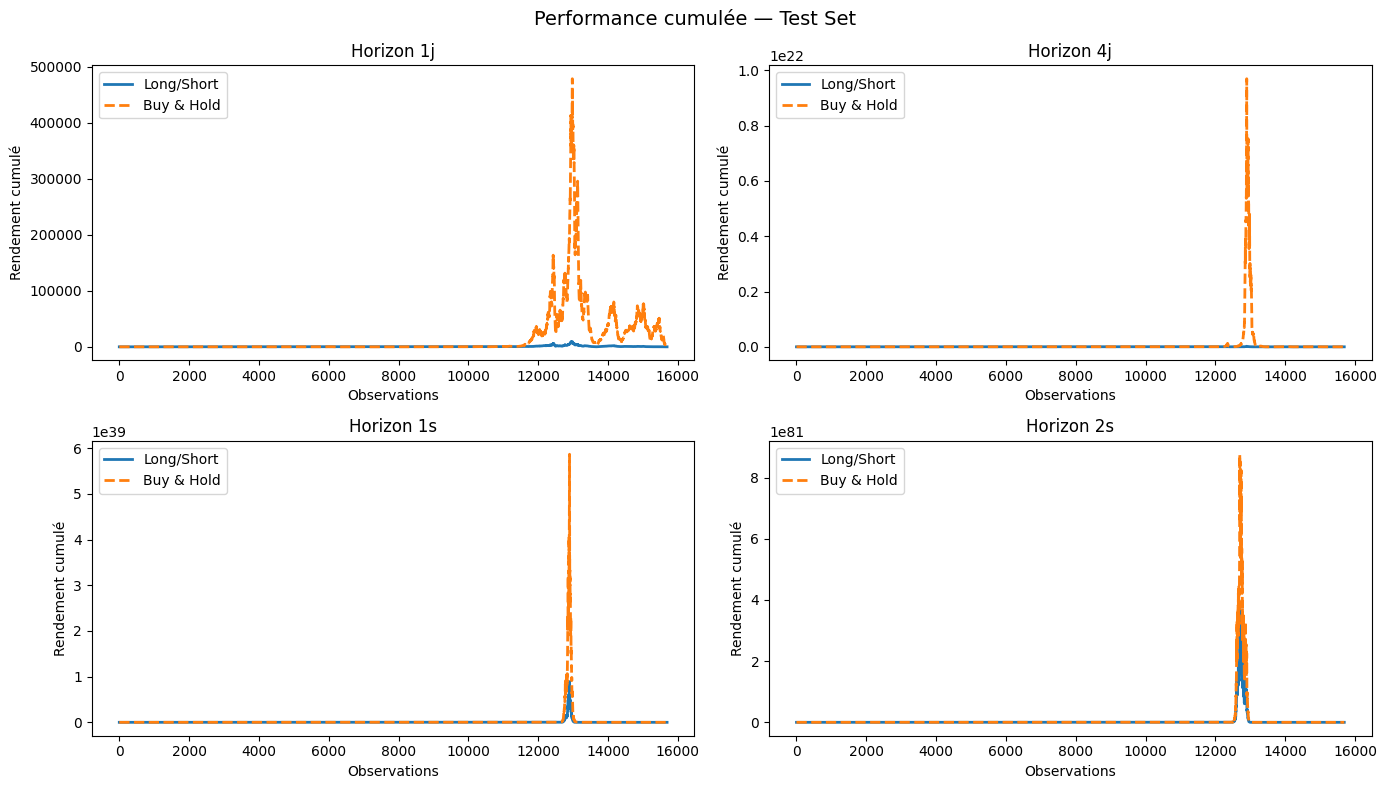

In [12]:
import matplotlib.pyplot as plt

rendement_cols = {
    '1j': 'decision(rendement_brut_1j)',
    '4j': 'decision(rendement_brut_4j)',
    '1s': 'decision(rendement_brut_1s)',
    '2s': 'decision(rendement_brut_2s)'
}

# Récupération des rendements bruts depuis df_v1
rend_df = df_v1[['Date', 'ticker'] + list(rendement_cols.values())].copy()
rend_df['Date'] = pd.to_datetime(rend_df['Date'], utc=True).dt.tz_localize(None)
test_df_rend = test_df.merge(rend_df, on=['Date', 'ticker'], how='left')

def sharpe(returns, ann=252):
    if returns.std() == 0:
        return 0
    return (returns.mean() / returns.std()) * np.sqrt(ann)

sharpe_results = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, name in enumerate(['1j', '4j', '1s', '2s']):
    rendements_reels = test_df_rend[rendement_cols[name]].values.astype(float)
    y_pred           = metrics[name]['y_pred_test']
    signal           = np.where(y_pred == 1, 1, -1)

    strat_returns = signal * rendements_reels
    bh_returns    = rendements_reels

    sharpe_strat = sharpe(strat_returns)
    sharpe_bh    = sharpe(bh_returns)
    sharpe_results[name] = {'strat': sharpe_strat, 'bh': sharpe_bh}

    print(f"=== Horizon {name} ===")
    print(f"Sharpe stratégie : {sharpe_strat:.3f} | Sharpe B&H : {sharpe_bh:.3f}")
    print(" Exploitable" if sharpe_strat > 0.5 else "  Peu exploitable")

    cumul_strat = (1 + strat_returns).cumprod()
    cumul_bh    = (1 + bh_returns).cumprod()

    axes[idx].plot(cumul_strat, label='Long/Short', linewidth=2)
    axes[idx].plot(cumul_bh,    label='Buy & Hold', linewidth=2, linestyle='--')
    axes[idx].set_title(f'Horizon {name}')
    axes[idx].set_xlabel('Observations')
    axes[idx].set_ylabel('Rendement cumulé')
    axes[idx].legend()

plt.suptitle('Performance cumulée — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

## Conclusion

Les performances obtenues ne correspondent pas entièrement à celles que nous aurions initialement espérées. Néanmoins, ces premiers résultats restent encourageants dans le cadre d’une première approche du problème.

En effet, la prédiction des marchés financiers constitue une tâche particulièrement complexe en raison du bruit, de la non-stationnarité des données et de la faible présence de signaux exploitables. Malgré cela, notre modèle parvient à atteindre une accuracy d’environ 0,55, tout en évitant le surapprentissage, ce qui suggère qu’il capte un signal prédictif réel, bien que modéré.

Ces résultats constituent donc une base solide pour les itérations futures du projet. Des améliorations pourront être envisagées, notamment à travers l’enrichissement des variables explicatives, l’adaptation des méthodes de validation aux séries temporelles, ainsi que l’optimisation des modèles.

Ainsi, cette première version du projet met en évidence le potentiel de l’approche adoptée et ouvre des perspectives intéressantes pour la suite.